# Py09: Regression 1: Simple Linear Regression


In [ ]:
#%pip install statsmodels

In [1]:
# Load your data and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = 'ames_lite.csv'
df_raw = pd.read_csv(path)

number_columns = df_raw.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()

print("DataFrame dtypes:")
print(df_raw.dtypes)
df_raw.describe()

df_raw

DataFrame dtypes:
building_type           str
central_ac_yn           str
sq_ft_first_floor     int64
sq_ft_second_floor    int64
bathrooms             int64
bedrooms              int64
year_sold             int64
sale_price            int64
dtype: object


/var/folders/w6/p7gv5g6166vbk07p2pwdxjqr0000gp/T/ipykernel_22872/3859598983.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()


,building_type,central_ac_yn,sq_ft_first_floor,sq_ft_second_floor,bathrooms,bedrooms,year_sold,sale_price
0,OneFam,Y,916,910,1,4,2009,155000
1,OneFam,Y,1291,0,1,2,2008,173000
2,Duplex,N,1088,1040,2,4,2009,62500
3,OneFam,Y,662,662,1,3,2010,122000
4,OneFam,Y,967,0,1,2,2007,99900
...,...,...,...,...,...,...,...,...
2529,OneFam,Y,4692,950,2,3,2008,160000
2530,OneFam,Y,1533,0,2,2,2006,280000
2531,OneFam,Y,1824,0,2,2,2007,302000
2532,OneFam,Y,1444,700,2,4,2007,277000


# Step 1: Data Quality

Examine these fields for data issues. Describe each of these fields. 

building_type: string with values OneFam or Duplex
central_ac_yn: string with values Y or N
sq_ft_first_floor: integer representing square footage
sq_ft_second_floor: integer representing square footage
bathrooms: integer representing number of bathrooms
bedrooms: integer representing number of bedrooms
year_sold: integer representing the year sold
sale_price: integer representing the sale price

Data Cleanup Steps:

- Create a new df to work with
- Convert any text columns that can be easily categorized to 1/0
- Combine related columns
- Remove rows with extreme values (e.g., above 99th percentile)


In [2]:
# Data Cleanup

# Step 0: Create a new df to work with 
df = df_raw.copy()

# Step 1: Feature creation:

# Convert the Y/N category variable to 1/0
df['central_ac01'] = df['central_ac_yn'].map({'Y': 1, 'N': 0})

# Convert the duplix to a 1/0 variable
df['is_duplix01'] = np.where(df['building_type'] == 'Duplex', 1, 0)


# Create a new column combining sq footage of basement and first floor
df['total_sqft'] = df['sq_ft_first_floor'] + df['sq_ft_second_floor']

# Remove old columns
df = df.drop(columns=['central_ac_yn', 'sq_ft_first_floor', 'sq_ft_second_floor', 'building_type'])

# Step 2: Remove outliers
old_record_count = df.shape[0]

# Remove rows with extreme sale prices (e.g., above 99th percentile)
upper_limit = df['sale_price'].quantile(0.99)
df = df[df['sale_price'] <= upper_limit]

# Remove rows with extreme square footage (e.g., above 99th percentile)
upper_sqft_limit = df['total_sqft'].quantile(0.99)
df = df[df['total_sqft'] <= upper_sqft_limit]

print(f"Removed {old_record_count - df.shape[0]} outlier records")

Removed 52 outlier records


# Step 2: Visualize data

Use a pairplot and histograms to visualize the data.

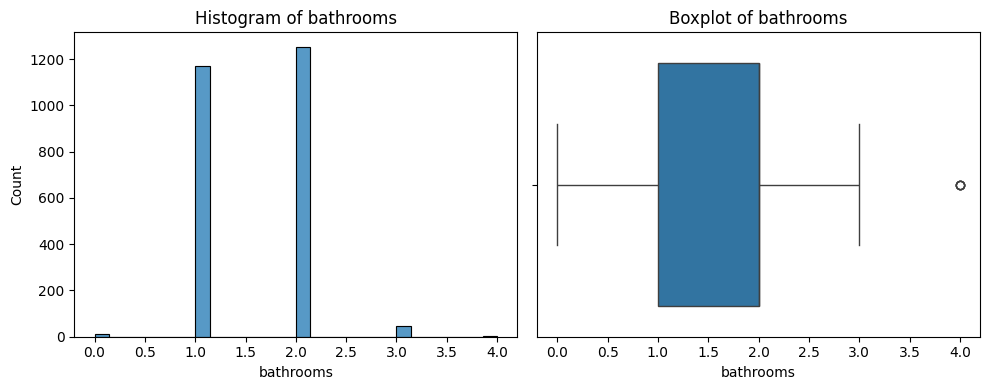

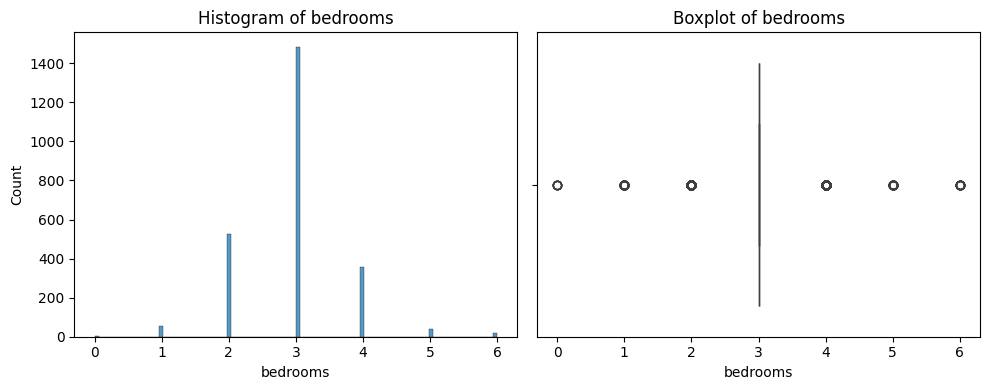

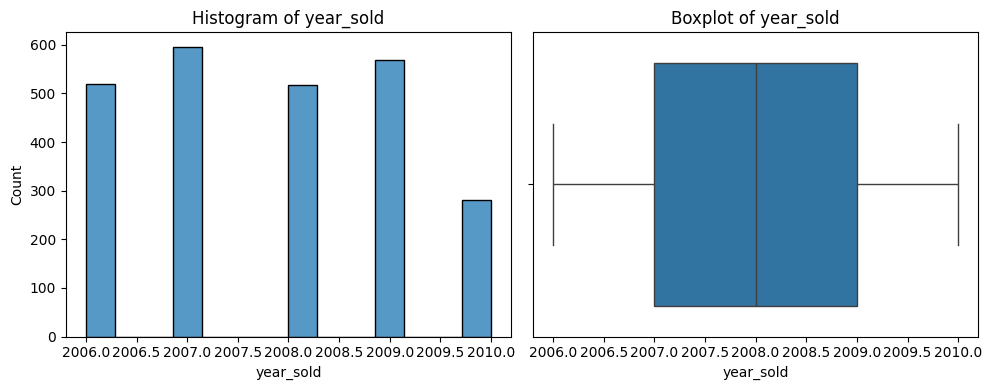

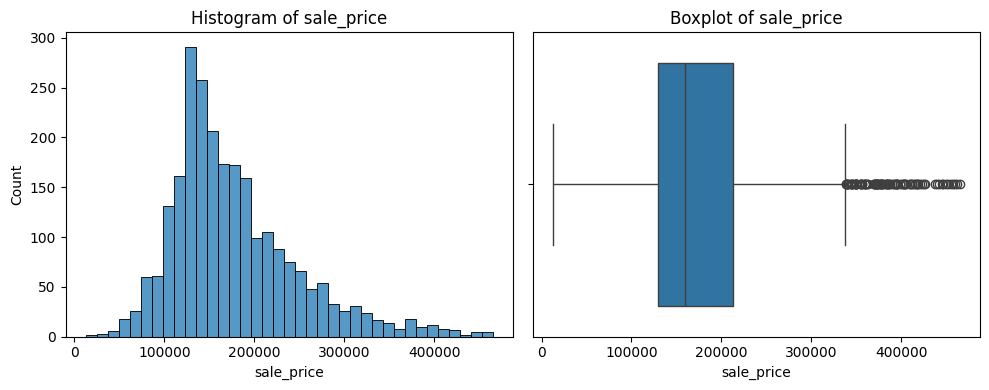

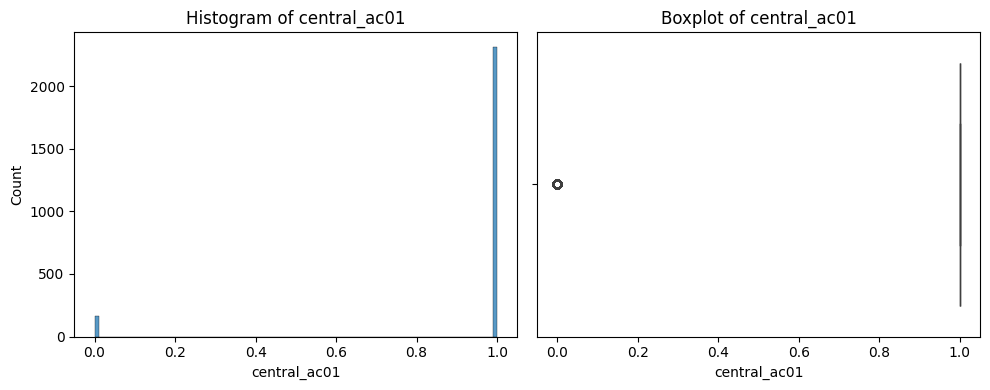

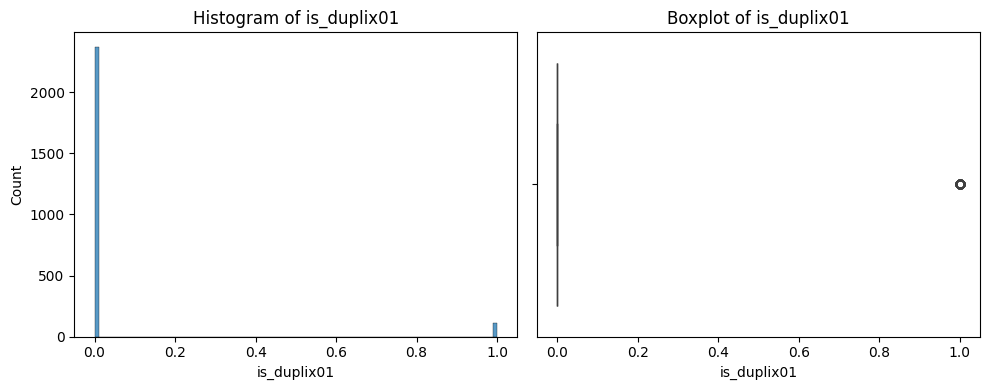

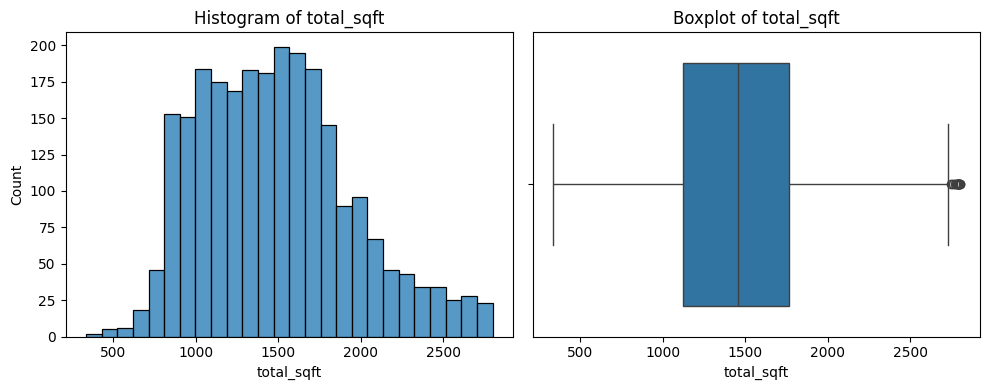

In [3]:
# Plot each numeric variable

number_columns = df.select_dtypes(include=['number']).columns.tolist()
text_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in number_columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col])
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()


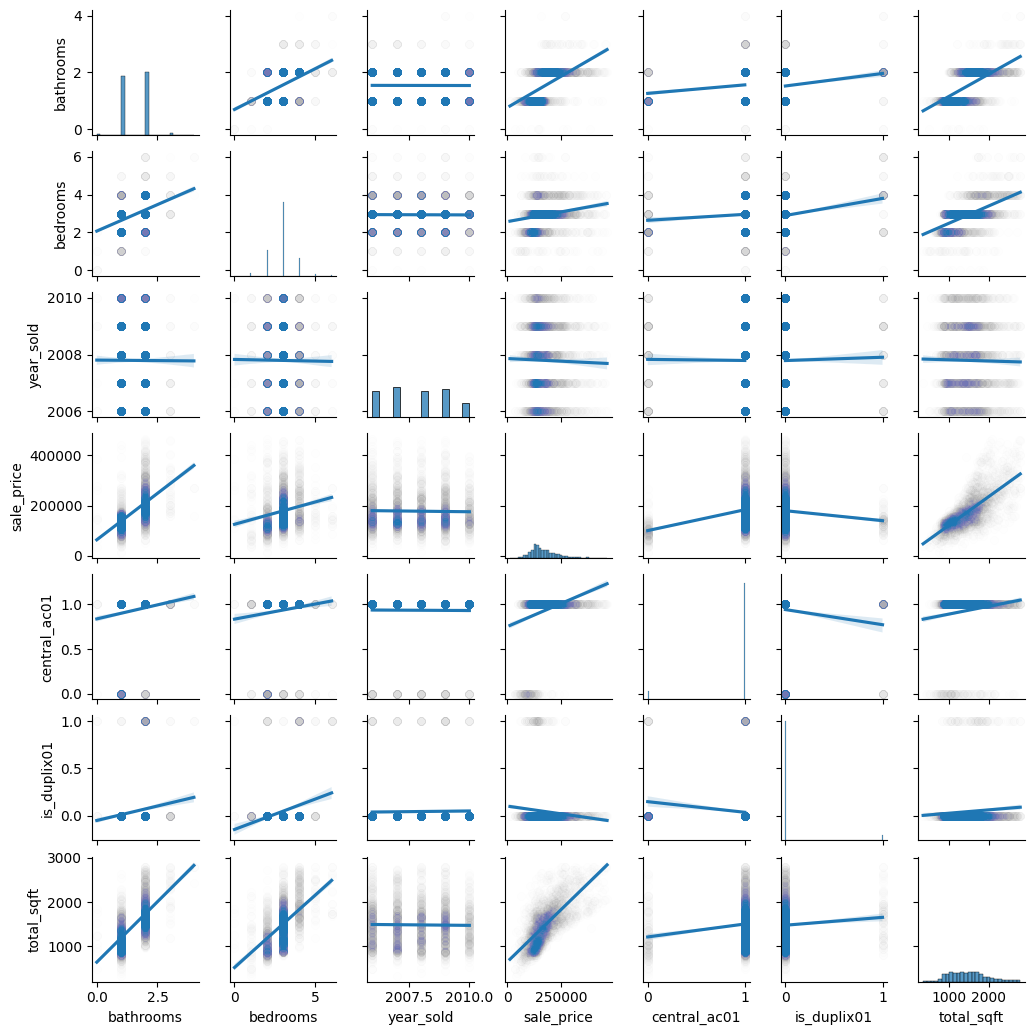

In [9]:
# Plot a pairs printout of each of the numeric variables
sns.pairplot(df, kind='reg', height=1.5, plot_kws={'scatter_kws': {'alpha': 0.005}})
plt.show()

# Step 3: Build a simple linear regression model

Key items:

- Residuals = errors in each row between actual & predicted
- Standard Error = the squared difference between the predicted and actual values. 
- Coefficients:
  - Estimate: value of the change in input to output
  - Standard Error: averages squared diff between prediction / actual
  - p Value: probability of the estimate being a result of random chance
- Residual standard error: the overall avg difference between actual
    and predicted for the entire model.
  - Adj R^2,  the % of variation explained by the model

In [17]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# print up to 4 significant digits in the summary output
pd.options.display.float_format = '{:5f}'.format

# Get variables for prediction
X = df[['bathrooms', 'total_sqft', 'central_ac01']]
y = df['sale_price']

# Fit the model
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
predictions = model.predict(X)


pd.set_option('display.float_format', lambda x: '%.10f' % x)
# Now calling print(model.summary()) or viewing tables may show more digits

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             sale_price   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     1128.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:11:58   Log-Likelihood:                -30191.
No. Observations:                2482   AIC:                         6.039e+04
Df Residuals:                    2478   BIC:                         6.041e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -3.792e+04   4420.416     -8.579   

RMSE: 42583.83679244068
R²: 0.6438843506775023


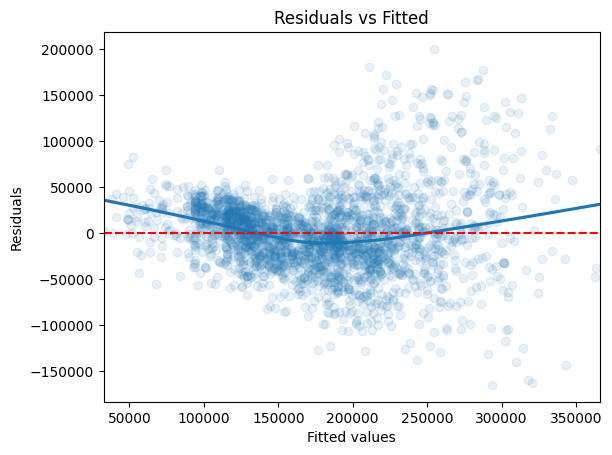

In [6]:
resid = model.resid
fitted = model.fittedvalues
rmse_value = np.sqrt(np.mean(resid**2))
print(f"RMSE: {rmse_value}")
r2_value = model.rsquared
print(f"R²: {r2_value}")

# Plot resduals
sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha': 0.1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.axhline(0, color='red', linestyle='--')
plt.show()